In [1]:
!pip install wordcloud


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
df = pd.read_csv('spam.csv',encoding='latin-1')
df = df[['v1','v2']]
df.columns = ['label','message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


<Axes: xlabel='label'>

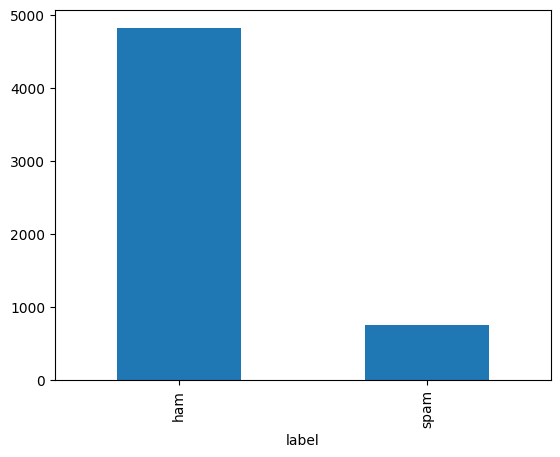

In [4]:
df['label'].value_counts().plot(kind='bar')

In [5]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [6]:
df['label_encoded'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()

,label,message,label_encoded
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


<Axes: xlabel='label'>

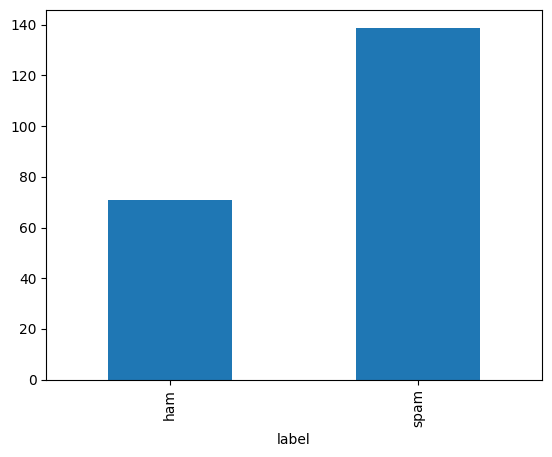

In [7]:
df['msg_length'] = df['message'].apply(len)
df.groupby('label')['msg_length'].mean().plot(kind='bar')

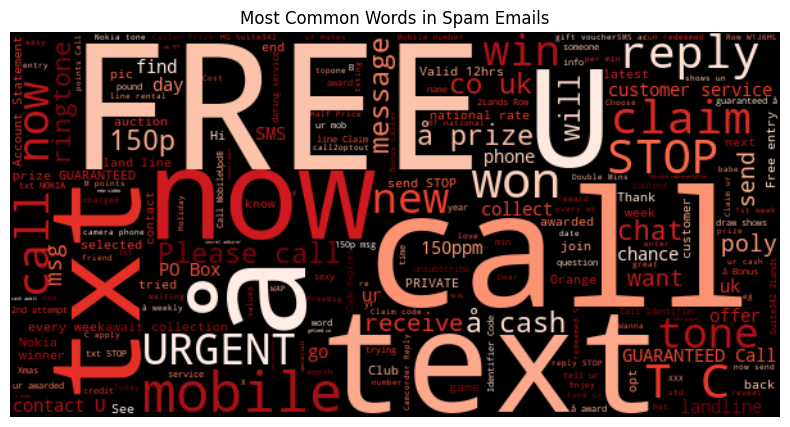

In [8]:
spam_words = " ".join(df[df["label"] == "spam"]["message"])

wordcloud = WordCloud(width=600, height=300, background_color="black", colormap="Reds").generate(spam_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Spam Emails")
plt.show()

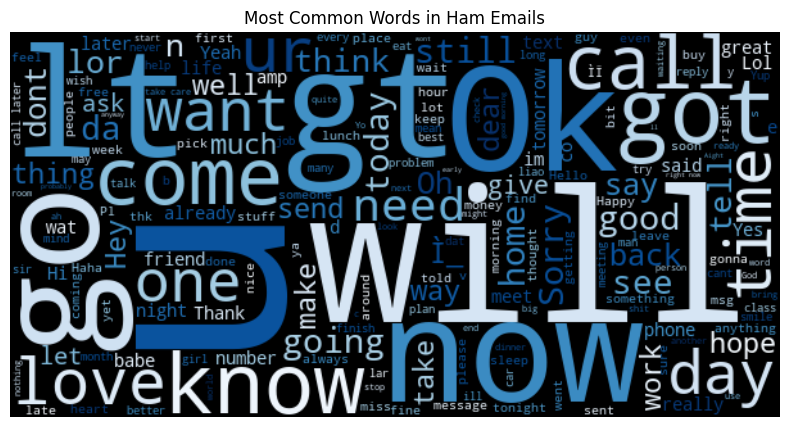

In [9]:
ham_words = " ".join(df[df["label"] == "ham"]["message"])

wordcloud = WordCloud(width=600, height=300, background_color="black", colormap="Blues").generate(ham_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Ham Emails")
plt.show()

In [11]:
X = df['message']
y = df['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [12]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [14]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

In [15]:
acc = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {acc:.4f}")

Naive Bayes Accuracy: 0.9722


In [18]:
print(classification_report(y_test, y_pred_nb, target_names=["Ham", "Spam"]))

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       0.99      0.80      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [19]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {acc_lr:.4f}")
print(classification_report(y_test, y_pred_lr, target_names=["Ham", "Spam"]))

Logistic Regression Accuracy: 0.9704
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



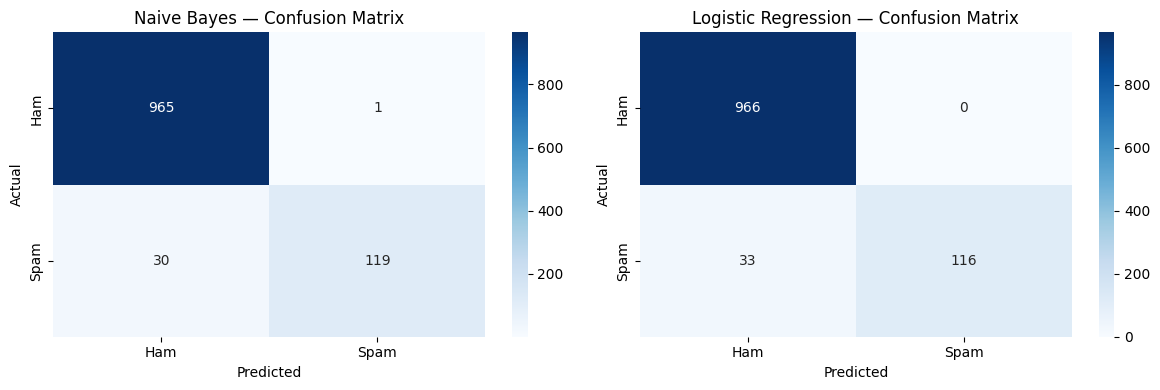

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(axes, 
                              [y_pred_nb, y_pred_lr], 
                              ["Naive Bayes", "Logistic Regression"]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=["Ham", "Spam"], 
                yticklabels=["Ham", "Spam"], ax=ax)
    ax.set_title(f"{title} — Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [21]:
def predict_spam(email_text,model=lr_model):
    email_tfidf = tfidf.transform([email_text])
    prediction = model.predict(email_tfidf)[0]
    probability = model.predict_proba(email_tfidf)[0][prediction]
    label = "Spam" if prediction == 1 else "Ham"
    return label, probability

test_email = "Congratulations! You've won a free ticket. Click here to claim."
label, prob = predict_spam(test_email)
print(f"Email: {test_email}\nPredicted Label: {label}\nProbability: {prob:.4f}")

Email: Congratulations! You've won a free ticket. Click here to claim.
Predicted Label: Spam
Probability: 0.6232
